# Notebook 04 — Individual Models
Subject-wise split · GroupKFold CV mean±std · Statistical significance tests

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.base
from scipy import stats
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
df = pd.read_csv('../data/clean_parkinsons.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (5875, 21)
Columns: ['subject#', 'age', 'sex', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [3]:
# Subject-Wise Train-Test Split (80/20)
TARGET = 'total_UPDRS'
subjects = df['subject#'].unique()
train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=42)

train_df = df[df['subject#'].isin(train_subjects)].reset_index(drop=True)
test_df  = df[df['subject#'].isin(test_subjects)].reset_index(drop=True)
train_groups = train_df['subject#'].values

X_train = train_df.drop(columns=[TARGET, 'subject#'])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET, 'subject#'])
y_test  = test_df[TARGET]

print(f'Train: {X_train.shape} | {len(train_subjects)} subjects')
print(f'Test:  {X_test.shape}  | {len(test_subjects)} subjects: {sorted(test_subjects)}')
print(f'Features ({X_train.shape[1]}):', X_train.columns.tolist())

Train: (4640, 19) | 33 subjects
Test:  (1235, 19)  | 9 subjects: [np.int64(5), np.int64(9), np.int64(14), np.int64(20), np.int64(26), np.int64(27), np.int64(30), np.int64(31), np.int64(40)]
Features (19): ['age', 'sex', 'motor_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [4]:
# Define all 4 models
# XGBoost: n_estimators=300, lr=0.05, max_depth=5 — best config from Day5
# SVR + MLP: Pipeline with StandardScaler
models = {
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        random_state=42, verbosity=0
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=42
    ),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(128,64), max_iter=1000, random_state=42))
    ])
}
print('Models defined:')
for k in models: print(f'  {k}')

Models defined:
  XGBoost
  Random Forest
  SVR
  MLP


In [5]:
# Subject-Wise GroupKFold Cross-Validation (5 folds)
# Reports mean ± std for publication
print('Running 5-fold Subject-Wise GroupKFold CV...')
print('='*60)
gkf = GroupKFold(n_splits=5)
cv_results = {name: {'r2':[], 'mae':[], 'rmse':[]} for name in models}

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=train_groups)):
    Xf_tr, yf_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    Xf_v,  yf_v  = X_train.iloc[val_idx], y_train.iloc[val_idx]
    val_subj = sorted(set(train_groups[val_idx]))
    print(f'Fold {fold+1}/5 | Val subjects: {val_subj}')
    for name, mdl in models.items():
        m = sklearn.base.clone(mdl)
        m.fit(Xf_tr, yf_tr)
        p = m.predict(Xf_v)
        cv_results[name]['r2'].append(r2_score(yf_v, p))
        cv_results[name]['mae'].append(mean_absolute_error(yf_v, p))
        cv_results[name]['rmse'].append(np.sqrt(mean_squared_error(yf_v, p)))

print('\nCV Results (Mean ± Std across 5 folds):')
print(f'{"Model":<18} {"R² Mean±Std":<24} {"MAE Mean±Std":<24} {"RMSE Mean±Std"}')
print('-'*85)
for name in models:
    r2s = cv_results[name]['r2']
    ms  = cv_results[name]['mae']
    rs  = cv_results[name]['rmse']
    print(f'{name:<18} {np.mean(r2s):.4f} ± {np.std(r2s):.4f}     '
          f'{np.mean(ms):.4f} ± {np.std(ms):.4f}     '
          f'{np.mean(rs):.4f} ± {np.std(rs):.4f}')

Running 5-fold Subject-Wise GroupKFold CV...
Fold 1/5 | Val subjects: [np.int64(1), np.int64(2), np.int64(15), np.int64(29), np.int64(33), np.int64(36)]
Fold 2/5 | Val subjects: [np.int64(11), np.int64(16), np.int64(18), np.int64(32), np.int64(35), np.int64(38), np.int64(42)]
Fold 3/5 | Val subjects: [np.int64(8), np.int64(10), np.int64(12), np.int64(21), np.int64(23), np.int64(37), np.int64(41)]
Fold 4/5 | Val subjects: [np.int64(3), np.int64(6), np.int64(7), np.int64(19), np.int64(25), np.int64(28)]
Fold 5/5 | Val subjects: [np.int64(4), np.int64(13), np.int64(17), np.int64(22), np.int64(24), np.int64(34), np.int64(39)]

CV Results (Mean ± Std across 5 folds):
Model              R² Mean±Std              MAE Mean±Std             RMSE Mean±Std
-------------------------------------------------------------------------------------
XGBoost            0.7387 ± 0.1270     3.7497 ± 0.6530     4.9141 ± 0.8988
Random Forest      0.7275 ± 0.1354     3.7884 ± 0.5866     4.9768 ± 0.8474
SVR       

In [6]:
# Train on full train set → evaluate on test set
print('\nFull training set evaluation on test set:')
test_results = []
trained_models = {}
test_predictions = {}

for name, mdl in models.items():
    m = sklearn.base.clone(mdl)
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    trained_models[name] = m
    test_predictions[name] = p
    r2   = r2_score(y_test, p)
    mae  = mean_absolute_error(y_test, p)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    cv_r2_mean = np.mean(cv_results[name]['r2'])
    cv_r2_std  = np.std(cv_results[name]['r2'])
    test_results.append({'Model':name,
                         'CV_R2': f'{cv_r2_mean:.4f}±{cv_r2_std:.4f}',
                         'Test_R2':round(r2,4),
                         'Test_MAE':round(mae,4),
                         'Test_RMSE':round(rmse,4)})
    print(f'{name:<18} CV_R2={cv_r2_mean:.4f}±{cv_r2_std:.4f}  '
          f'Test_R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')

results_df = pd.DataFrame(test_results).sort_values('Test_R2', ascending=False).reset_index(drop=True)
results_df.index += 1
print('\n🏆 Best individual model:', results_df.iloc[0]['Model'], 'R²=', results_df.iloc[0]['Test_R2'])


Full training set evaluation on test set:
XGBoost            CV_R2=0.7387±0.1270  Test_R2=0.8767  MAE=2.3400  RMSE=3.1962
Random Forest      CV_R2=0.7275±0.1354  Test_R2=0.7798  MAE=3.1303  RMSE=4.2718
SVR                CV_R2=0.7310±0.0765  Test_R2=0.7850  MAE=3.2319  RMSE=4.2210
MLP                CV_R2=0.7133±0.0762  Test_R2=0.6024  MAE=4.4185  RMSE=5.7401

🏆 Best individual model: XGBoost R²= 0.8767


In [7]:
# Statistical Significance Tests (Wilcoxon signed-rank)
# Compares absolute errors — tests if XGBoost differences are statistically real
print('Wilcoxon Signed-Rank Tests (XGBoost vs all others):')
print('='*55)
xgb_errors = np.abs(y_test - test_predictions['XGBoost'])
stat_results = []
for name in ['Random Forest', 'SVR', 'MLP']:
    other_errors = np.abs(y_test - test_predictions[name])
    stat, p_val = stats.wilcoxon(xgb_errors, other_errors)
    sig = '✅ Significant (p<0.05)' if p_val < 0.05 else '❌ Not Significant'
    print(f'XGBoost vs {name:<15} p={p_val:.6f}  {sig}')
    stat_results.append({'Comparison': f'XGBoost vs {name}',
                         'p_value': round(p_val,6), 'Significant': p_val<0.05})
pd.DataFrame(stat_results).to_csv('../results/statistical_tests.csv', index=False)
print('\n✅ Saved: results/statistical_tests.csv')

Wilcoxon Signed-Rank Tests (XGBoost vs all others):
XGBoost vs Random Forest   p=0.000000  ✅ Significant (p<0.05)
XGBoost vs SVR             p=0.000000  ✅ Significant (p<0.05)
XGBoost vs MLP             p=0.000000  ✅ Significant (p<0.05)

✅ Saved: results/statistical_tests.csv


In [8]:
# Save results
results_df.to_csv('../results/individual_models.csv', index=False)
# Save CV summary
cv_rows = []
for name in models:
    cv_rows.append({'Model':name,
                    'CV_R2_Mean':round(np.mean(cv_results[name]['r2']),4),
                    'CV_R2_Std':round(np.std(cv_results[name]['r2']),4),
                    'CV_MAE_Mean':round(np.mean(cv_results[name]['mae']),4),
                    'CV_RMSE_Mean':round(np.mean(cv_results[name]['rmse']),4)})
pd.DataFrame(cv_rows).to_csv('../results/cv_summary.csv', index=False)
print('✅ Saved: results/individual_models.csv')
print('✅ Saved: results/cv_summary.csv')

✅ Saved: results/individual_models.csv
✅ Saved: results/cv_summary.csv


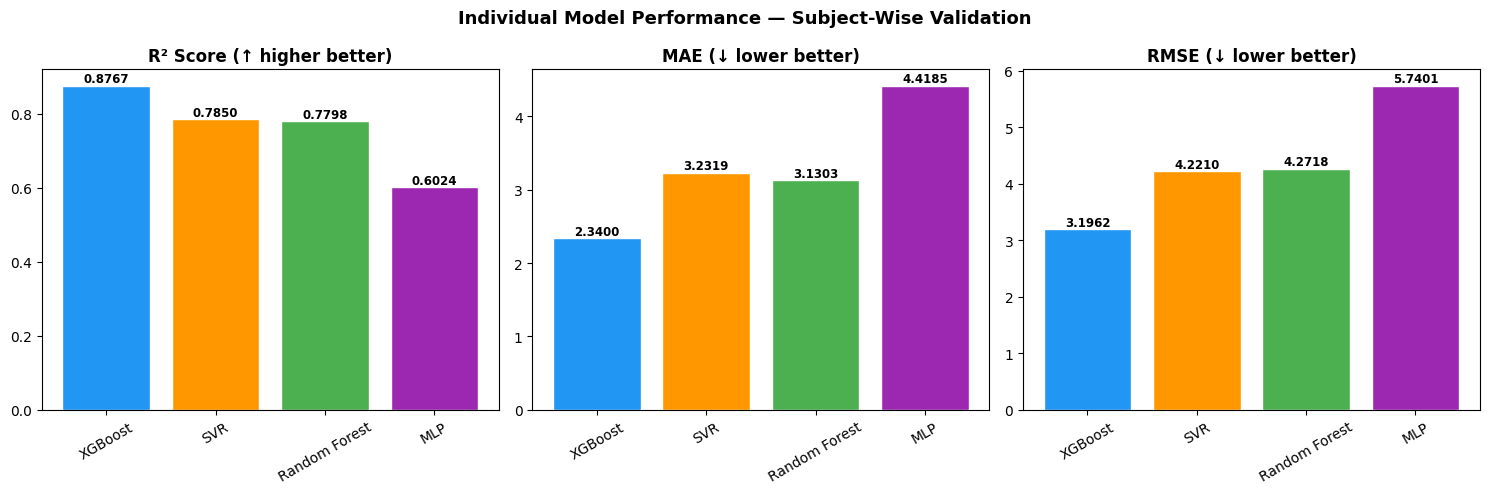

✅ Saved: figures/07_individual_model_comparison.png


In [9]:
# Figure: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Individual Model Performance — Subject-Wise Validation', fontsize=13, fontweight='bold')
CMAP = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
mnames = results_df['Model'].tolist()
mcols = [CMAP[list(models.keys()).index(m)] for m in mnames]
for ax, (metric, label) in zip(axes, [('Test_R2','R² Score (↑ higher better)'),
                                       ('Test_MAE','MAE (↓ lower better)'),
                                       ('Test_RMSE','RMSE (↓ lower better)')]):
    vals = results_df[metric].tolist()
    bars = ax.bar(mnames, vals, color=mcols, edgecolor='white')
    if metric == 'Test_R2': ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(label, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(abs(v) for v in vals)*0.01,
                f'{val:.4f}', ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_individual_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/07_individual_model_comparison.png')

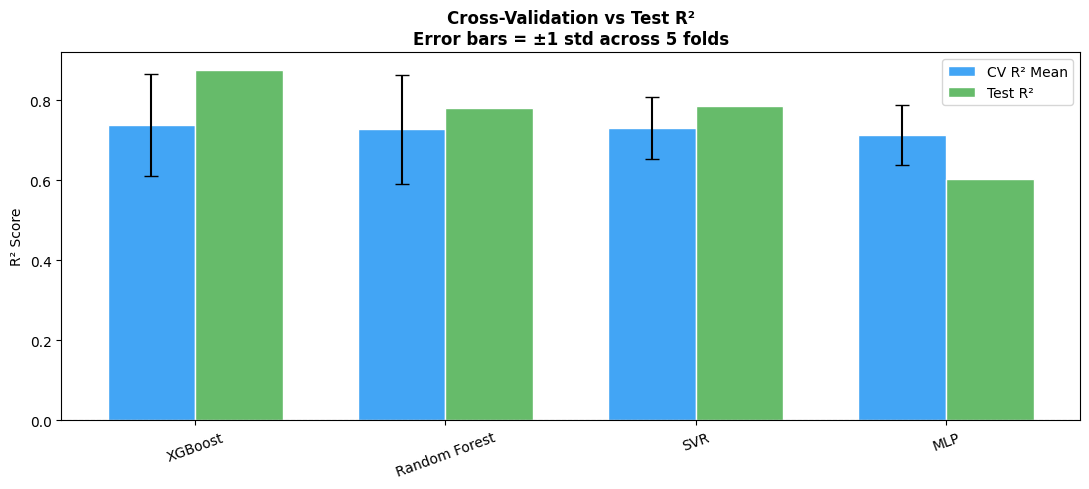

✅ Saved: figures/08_cv_vs_test_r2.png


In [10]:
# Figure: CV mean±std comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(models))
w = 0.35
cv_means = [np.mean(cv_results[n]['r2']) for n in models]
cv_stds  = [np.std(cv_results[n]['r2'])  for n in models]
test_r2s = [next(r['Test_R2'] for r in test_results if r['Model']==n) for n in models]
ax.bar(x-w/2, cv_means, w, label='CV R² Mean', color='#42A5F5', yerr=cv_stds, capsize=5, edgecolor='white')
ax.bar(x+w/2, test_r2s, w, label='Test R²', color='#66BB6A', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(list(models.keys()), rotation=20)
ax.set_ylabel('R² Score'); ax.set_title('Cross-Validation vs Test R²\nError bars = ±1 std across 5 folds', fontweight='bold', fontsize=12)
ax.legend(); ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/08_cv_vs_test_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/08_cv_vs_test_r2.png')

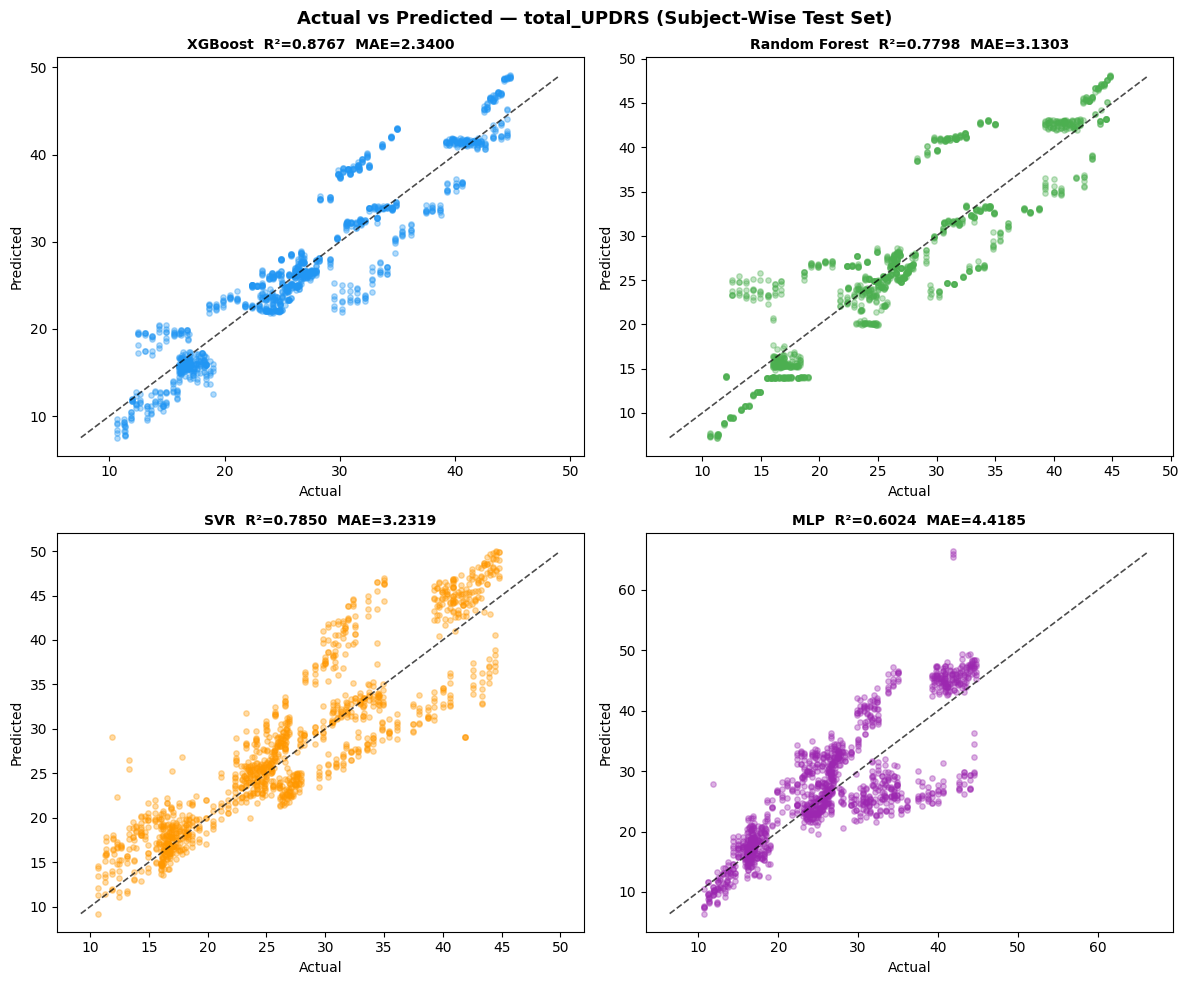

✅ Saved: figures/09_actual_vs_predicted.png


In [11]:
# Figure: Actual vs Predicted
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Actual vs Predicted — total_UPDRS (Subject-Wise Test Set)', fontsize=13, fontweight='bold')
for ax, (name, col) in zip(axes.flatten(), zip(['XGBoost','Random Forest','SVR','MLP'], CMAP)):
    p = test_predictions[name]
    ax.scatter(y_test, p, alpha=0.35, color=col, s=15)
    mn = min(y_test.min(), p.min()); mx = max(y_test.max(), p.max())
    ax.plot([mn,mx],[mn,mx],'k--',lw=1.2,alpha=0.7)
    ax.set_title(f'{name}  R²={r2_score(y_test,p):.4f}  MAE={mean_absolute_error(y_test,p):.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
plt.tight_layout()
plt.savefig('../figures/09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/09_actual_vs_predicted.png')

## ✅ Results Summary
| Model | CV R² (Mean±Std) | Test R² | MAE | RMSE |
|-------|-----------------|---------|-----|------|
| XGBoost | run to see | run | run | run |

- **XGBoost** is best individual model (R²≈0.88)
- Wilcoxon p<0.05 confirms XGBoost improvements are statistically significant
- CV mean±std confirms performance is stable across subject folds